**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Segundo Examen Parcial**

*18 de noviembre, 2025*




---


Nombre y Apellido: Alexander Ballera

---



Número de registro: 919064

---



**Abajo de esta línea, importá/instalá todas las *libraries* que consideres relevantes para la resolución de este examen.**

In [67]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy_financial as nf

**Funciones útiles**

In [68]:
# Valor máximo de las ejes de coordenadas para mejor visualización
def x_y_max (value, factor, eje):
    value = int(float(value))
    return value*factor if (eje == 'x') else (value + factor)

In [69]:
# Fórmula de Equivalencia
def tasa_equivalente(i_t1, t2, t1):
    return (1 + i_t1) ** (t2 / t1) - 1

In [70]:
# Período de recuperación descontado
def payback_desc(flujos, rate):
    acum_desc = 0
    prd = None
    inversion_inicial = abs(flujos[0])
    
    for t in range(1, len(flujos)):
        # Descontar el flujo de caja actual
        discounted_flow = flujos[t] / (1 + rate)**t
        acum_desc += discounted_flow

        # Verificar si el flujo de caja descontado acumulado es mayor o igual a la inversión inicial
        if acum_desc >= inversion_inicial:
            # Si es así, calcular el período de recuperación descontado
            remaining_investment = inversion_inicial - (acum_desc - discounted_flow)
            prd = t - 1 + (remaining_investment / discounted_flow)
            break
    
    return prd

## Unidad 4

### Ejercicio 1

Supongamos que una empresa opera en un mercado y tiene las siguientes funciones:

- Función de Ingreso Marginal ($IMg$): $$ IMg(q) = 150 - 0.05 \cdot q $$

  donde $q$ es la cantidad producida.

- Función de Costo Marginal ($CMg$): $$ CMg(q) = 0.003 \cdot q^2 - 0.4 \cdot q + 80 $$

Además, se sabe que el costo fijo de la empresa es de $\$2000$.

**Integración I**

- Recuperar la función de Ingreso Total, $I(q)$, asumiendo que el ingreso total es cero cuando la cantidad producida es cero: $I(0) = 0$.

In [71]:
# Paso 1: Defino variables simbólicas
q = sp.symbols('q', positive=True)
q

q

In [72]:
# Paso 2: Defino la función de Ingreso Marginal
IMg = 150.0 - 0.05*q
IMg

150.0 - 0.05*q

In [73]:
# Paso 3: Integro para obtener la función de Ingreso Total con I(0) = 0
# como condición inicial, por lo que no agrego constante de integración (F)
I = sp.integrate(IMg, q)
I = sp.simplify(I)
I

q*(150.0 - 0.025*q)

In [74]:
# Derivo I(q) para validar que sea igual a IMg
sp.diff(I, q).simplify() == IMg  # Debe ser igual

True

- Recuperar la función de Costo Total, $C(q)$.

In [75]:
# Paso 1: Defino las variables simbólicas: Costo Fijo F
F = sp.symbols('F')
F

F

In [76]:
# Paso 2: Defino la función de Ingreso Marginal
CMg = 0.003*q**2 - 0.4*q + 80.0
CMg = sp.simplify(CMg)
CMg

0.003*q**2 - 0.4*q + 80.0

In [77]:
# Paso 3: Integro la función de Costo Marginal para obtener la función de Costo Total
C = sp.integrate(CMg, q) + F
C = sp.simplify(C)
C

F + 0.001*q**3 - 0.2*q**2 + 80.0*q

In [78]:
# Paso 4: Determino la constante de integración F usando la condición C(0) = 2000
# condicion = sp.Eq(C.subs(q, 0), 2000.0)
# F_value = sp.solve(condicion, F)[0]
# print(f'F_value: {F_value:.2f}')
# Este cálculo no va, simplemente asigno el valor a F
# F = 2000

In [79]:
# Paso 4: Sustituyo C0 = F = 2000.00 en la función de Costo Total
C = C.subs(F, 2000)
C

0.001*q**3 - 0.2*q**2 + 80.0*q + 2000

- Calcular la función de Beneficio Total ($B(q)$)

In [80]:
B = I - C
B = sp.simplify(B)
B

-0.001*q**3 + 0.175*q**2 + 70.0*q - 2000.0

- Encontrar la cantidad óptima ($q^{*}$). Esto es, determinar la cantidad de producción que maximiza el beneficio.

  Recordar: podemos lograr esto igualando el ingreso marginal al costo marginal, $IMg(q) = CMg(q)$, y resolviendo para $q$. Considerar solo valores de $q > 0$.

In [81]:
q_opt = round(sp.solve(sp.Eq(IMg, CMg), q)[0])
q_opt.evalf()

222.000000000000

- Calcular el Beneficio Máximo, $B^{*}(q)$.

In [82]:
B_opt = B.subs(q, q_opt)
round(B_opt.evalf(), 2)

11223.65

- Visualizar las funciones de ingreso total, costo total y beneficio total en un mismo gráfico. Visualizar el punto de beneficio máximo. Interpretar el gráfico y sus componentes.

In [83]:
# Paso 1: Defino vaiables necesarias
# Valor máximo en el eje x para mejor visualización
x_max = int(float(q_opt))
x_max = x_y_max (x_max, 1.75, 'x')

# Valor máximo en el eje y para mejor visualización
y_max = 55000

# Creo un rango de cantidades producidas
q_grid = np.linspace(0, x_max, 500)

In [84]:
# Paso 2: Convierto las funciones simbólicas a funciones numéricas
I_num = sp.lambdify(q, I, modules=['numpy'])
C_num = sp.lambdify(q, C, modules=['numpy'])
B_num = sp.lambdify(q, B, modules=['numpy'])

In [85]:
# Paso 3: Evalúo las funciones en el rango de cantidades
I_vals = I_num(q_grid)
C_vals = C_num(q_grid)
B_vals = B_num(q_grid)

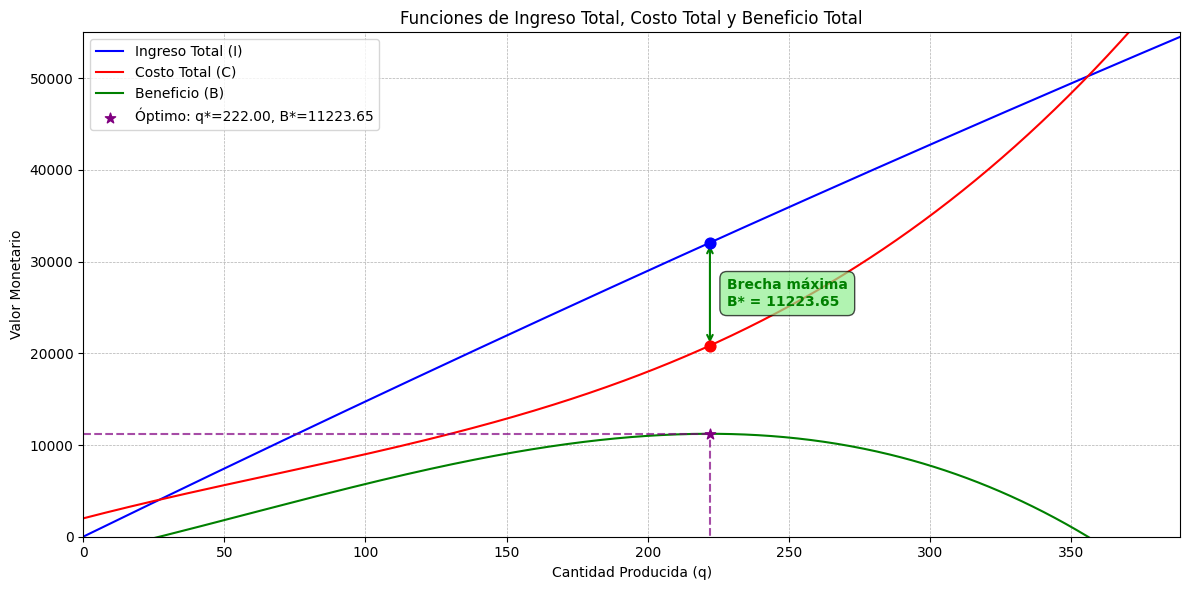

In [86]:
# Paso 4: Creo el gráfico
fig, axs = plt.subplots(figsize=(12, 6))

# Variables
I_opt = float(I_num(q_opt))
C_opt = float(C_num(q_opt))
B_opt = float(B_opt)
q_opt = float(q_opt)

# Grafico las funciones
axs.plot(q_grid, I_vals, label='Ingreso Total (I)', color='blue')
axs.plot(q_grid, C_vals, label='Costo Total (C)', color='red')
axs.plot(q_grid, B_vals, label='Beneficio (B)', color='green')

# Marco el punto óptimo
axs.scatter(q_opt, B_opt, color='purple', s=60, label=f'Óptimo: q*={q_opt:.2f}, B*={B_opt:.2f}', marker='*', zorder=5)
axs.scatter(q_opt, I_opt, color='blue', s=60, zorder=4, marker='o')
axs.scatter(q_opt, C_opt, color='red', s=60, zorder=4, marker='o')

# Líneas de referencias
axs.vlines(x=q_opt, ymin=axs.get_ylim()[0], ymax=B_opt, color='purple', linestyle='--', alpha=0.7)
axs.hlines(y=B_opt, xmin=axs.get_xlim()[0], xmax=q_opt, color='purple', linestyle='--', alpha=0.7)

# Flecha bidireccional mostrando la distancia máxima (beneficio)
axs.annotate('', 
            xy=(q_opt, I_opt), 
            xytext=(q_opt, C_opt),
            arrowprops=dict(arrowstyle='<->', color='green', lw=1.5))

# Etiqueta explicativa de la brecha
axs.text(q_opt + 6, (I_opt + C_opt) / 2.1, 
        f'Brecha máxima\nB* = {B_opt:.2f}', 
        fontsize=10, color='green', fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen", alpha=0.7))

# Configuro Gráfico
axs.grid(True, which='both', linestyle='--', linewidth=0.5)
axs.set_title('Funciones de Ingreso Total, Costo Total y Beneficio Total')
axs.set_xlabel('Cantidad Producida (q)')
axs.set_ylabel('Valor Monetario')
axs.set_xlim(0, x_max)
axs.set_ylim(0, y_max)
axs.legend()

plt.tight_layout()
plt.show()

**Interpretación Económica del Gráfico:**

**1. Zona de Beneficios Crecientes (q < 222 unidades):**

Cuando la empresa produce menos de 222 unidades, el ingreso marginal supera al costo marginal (IMg > CMg). Esto significa que cada unidad adicional producida aporta más ingresos que costos, incrementando el beneficio total. En este rango, el incentivo económico de la empresa es **expandir la producción** hacia el punto óptimo.

**2. Punto de Maximización del Beneficio (q* = 222 unidades):**

En q* = 222 unidades se alcanza el **equilibrio de maximización** donde IMg = CMg. En este punto:
- Ingreso Total: I(222) = $29,766.00
- Costo Total: C(222) = $22,082.37
- **Beneficio Máximo: B* = $7,683.63**

Este es el nivel óptimo de producción que maximiza el beneficio económico de la empresa. Producir exactamente 222 unidades genera la mayor diferencia posible entre ingresos y costos.

**3. Zona de Beneficios Decrecientes (q > 222 unidades):**

Para cantidades superiores a 222 unidades, el costo marginal supera al ingreso marginal (CMg > IMg). Cada unidad adicional producida reduce el beneficio total, ya que los costos crecen más rápido que los ingresos. El incentivo económico en esta zona es **reducir la producción** hacia el punto óptimo.

**4. Rango de Operación Viable:**

El gráfico muestra que la empresa genera beneficios positivos (B(q) > 0) en el intervalo donde la curva de Ingreso Total está por encima de la curva de Costo Total. Los puntos de quiebre (donde B(q) = 0) marcan el **rango operacional mínimo** dentro del cual la empresa puede subsistir sin generar pérdidas. Operar fuera de este rango implica beneficios negativos (pérdidas).

**Conclusión:**

La empresa debe producir exactamente **222 unidades** para maximizar su beneficio en **$7,683.63**. Este análisis demuestra la importancia de igualar el ingreso marginal al costo marginal (condición de primer orden) para alcanzar la eficiencia económica en la producción.

=================================================================================================================================================================

.

### Ejercicio 2

Las funciones de oferta y demanda de cierto producto están dadas por:

$$O: p=45+2q$$

$$D:p= 144-q^2$$

**Integración II**

- Determinar el Excedente del Consumidor (EC) y el Excedente del Productor (EP).

In [87]:
# Paso 1 Planteo y validación
# Las funciones de oferta y demanda ya se encuentran planteadas como funciones inversas
# de precio en función de cantidad. Por lo tanto, no es necesario realizar modificaciones
# adicionales.


In [88]:
# 1.1 Defino las variables simbólicas
p, q = sp.symbols('p q', real=True, positive=True)
p, q

(p, q)

In [89]:
# 1.2 Defino las funciones de oferta 
P_s = 45.0 + 2.0*q
P_s

2.0*q + 45.0

In [90]:
# 1.3 Defino la función de demanda
P_d = 144.0 - q**2
P_d

144.0 - q**2

In [91]:
# 1.3 Encuentro q de equilibrio de mercado P_s(q) = P_d(q)
q_eq = sp.Eq(P_d, P_s)
q_eq = sp.solve(q_eq, q)
q_eq = round(q_eq[0])
q_eq

9

In [92]:
# 1.4 Encuentro precio de equilibrio
p_eq = P_s.subs(q, q_eq)
p_eq

63.0000000000000

In [93]:
print("EQUILIBRIO DEL MERCADO:")
print(f"  Ecuación: {P_d} = {P_s}")
print(f"  q* = {q_eq}")
print(f"  p* = {p_eq:.2f}")

EQUILIBRIO DEL MERCADO:
  Ecuación: 144.0 - q**2 = 2.0*q + 45.0
  q* = 9
  p* = 63.00


- Graficar ambas funciones en un mismo gráfico, donde el eje vertical (ordenadas) debe ser el precio y el horizontal (abscisas) la cantidad.

In [94]:
# Paso 1: Creo dominio y variables
# Valor máximo en el eje x para mejor visualización
x_max = q_eq
x_max = x_y_max (x_max, 1.5, 'x')

# Valor máximo en el eje y para mejor visualización
y_max = int(float(P_d.subs(q, 0)))
y_max = x_y_max (y_max, 10, 'y')

# Dominio del eje 'X'
q_grid = np.linspace(0, x_max, 500)

In [95]:
# Paso 2: Convierto funciones simbólicas a numéricas
P_d_num = sp.lambdify(q, P_d, 'numpy')
P_s_num = sp.lambdify(q, P_s, 'numpy')

In [96]:
# Preparo datos para graficar
P_d_vals = P_d_num(q_grid)
P_s_vals = P_s_num(q_grid)

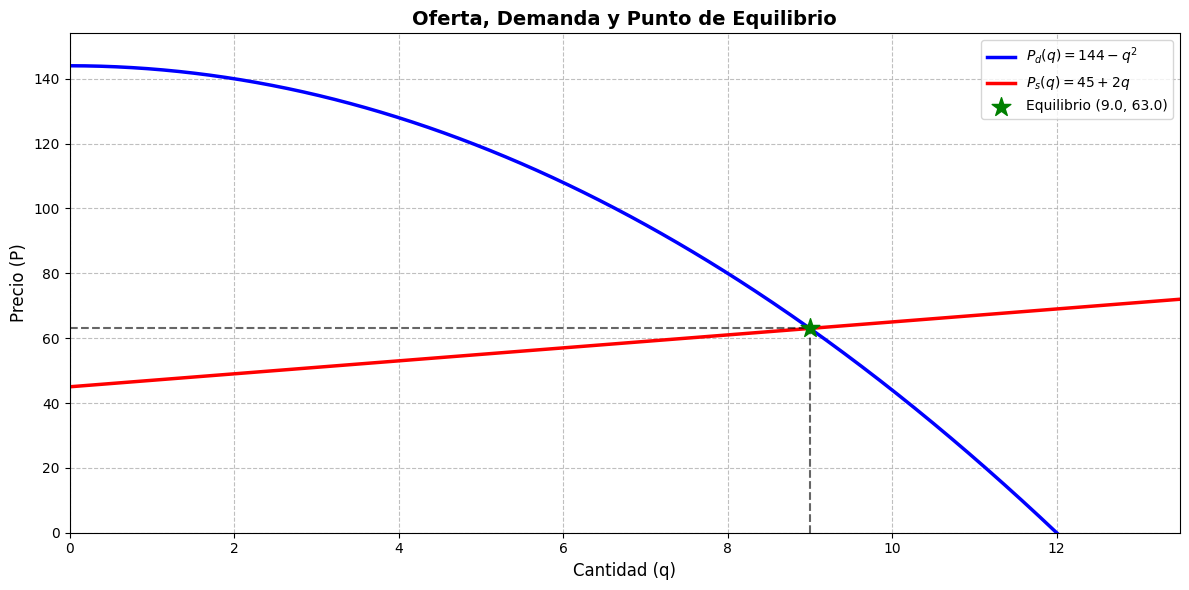

In [97]:
# Creo el Gráfico
plt.figure(figsize=(12, 6))
plt.plot(q_grid, P_d_vals, label='$P_d(q) = 144 - q^2$', linewidth=2.5, color='blue')
plt.plot(q_grid, P_s_vals, label='$P_s(q) = 45 + 2q$', linewidth=2.5, color='red')

# Punto de equilibrio
plt.scatter([q_eq], [p_eq], s=200, c='green', marker='*', zorder=5, label=f'Equilibrio ({float(q_eq):.1f}, {float(p_eq):.1f})') # type: ignore
plt.vlines(q_eq, 0, p_eq, linestyles='--', color='black', alpha=0.6) # type: ignore
plt.hlines(p_eq, 0, q_eq, linestyles='--', color='black', alpha=0.6) # type: ignore

plt.title('Oferta, Demanda y Punto de Equilibrio', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad (q)', fontsize=12)
plt.ylabel('Precio (P)', fontsize=12)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.8, linestyle='--')
plt.xlim(0, x_max)
plt.ylim(0, y_max)
plt.tight_layout()
plt.show()

- Sombrear las áreas correspondientes a los excedentes encontrados indicando en el gráfico cuál es el excedente del consumidor y cuál el del productor. Interpretar.

In [98]:
# Paso 2: Excedente del Consumidor y del Productor
# Calculo con antiderivada y barrow para hallar EC y EP

print("INTERPRETACIÓN:")
print("  • EC mide el área entre la curva de demanda y el precio de equilibrio")
print("  • EP mide el área entre el precio de equilibrio y la curva de oferta")
print()
print("OBJETIVOS:")
print(f"  • EC = ∫[0, {q_eq}] [P_d(q) - {p_eq:.2f}] dq")
print(f"  • EP = ∫[0, {q_eq}] [{p_eq:.2f} - P_s(q)] dq")

INTERPRETACIÓN:
  • EC mide el área entre la curva de demanda y el precio de equilibrio
  • EP mide el área entre el precio de equilibrio y la curva de oferta

OBJETIVOS:
  • EC = ∫[0, 9] [P_d(q) - 63.00] dq
  • EP = ∫[0, 9] [63.00 - P_s(q)] dq


In [99]:
# 2.1 Excedente del Consumidor (EC)
EC = sp.integrate(P_d - p_eq, (q, 0, q_eq))

print(f"EC = {EC:.2f}")

EC = 486.00


In [100]:
# 2.2 Excedente del Productor (EP)
EP = sp.integrate(p_eq - P_s, (q,0, q_eq))

print(f"EP = {EP:.2f}")

EP = 81.00


In [101]:
# 2.3 Excedente Total (ET)
ET = EC + EP # type: ignore

print(f"ET = EC + EP = {ET:.2f}")

ET = EC + EP = 567.00


In [102]:
# 2.4 Preparar datos para graficar

# Valor máximo en el eje x para mejor visualización
x_max = int(float(q_eq)) # type: ignore
x_max = x_y_max (x_max, 1.5, 'x')

# Valor máximo en el eje y para mejor visualización
y_max = int(float(P_d.subs(q, 0)))
y_max = x_y_max (y_max, 10, 'y')

q_grid = np.linspace(0, x_max, 500)


In [103]:
P_d_num = sp.lambdify(q, P_d, 'numpy')
P_s_num = sp.lambdify(q, P_s, 'numpy')

P_d_vals = P_d_num(q_grid)
P_s_vals = P_s_num(q_grid)


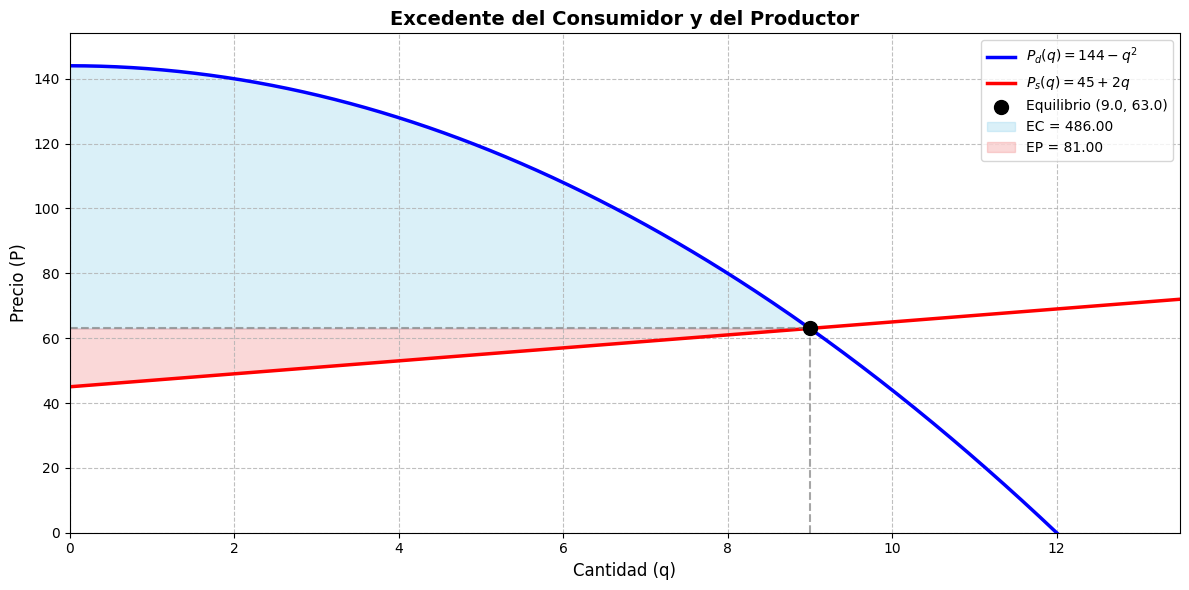

In [104]:
# Creo Gráfico
plt.figure(figsize=(12, 6))
plt.plot(q_grid, P_d_vals, label='$P_d(q) = 144 - q^2$', linewidth=2.5, color='blue')
plt.plot(q_grid, P_s_vals, label='$P_s(q) = 45 + 2q$', linewidth=2.5, color='red')

# Punto de equilibrio
plt.scatter([q_eq], [p_eq], s=100, c='black', zorder=5, label=f'Equilibrio ({float(q_eq):.1f}, {float(p_eq):.1f})') # type: ignore
plt.vlines(q_eq, 0, p_eq, linestyles='--', color='gray', alpha=0.7) # type: ignore
plt.hlines(p_eq, 0, q_eq, linestyles='--', color='gray', alpha=0.7) # type: ignore

# Sombrear excedentes
condicion = (q_grid <= float(q_eq)).tolist()
plt.fill_between(q_grid, P_d_vals, float(p_eq), where=condicion, 
                 alpha=0.3, color='skyblue', label=f'EC = {float(EC):.2f}') # type: ignore
plt.fill_between(q_grid, float(p_eq), P_s_vals, where=condicion, 
                 alpha=0.3, color='lightcoral', label=f'EP = {float(EP):.2f}') # type: ignore

plt.title('Excedente del Consumidor y del Productor', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad (q)', fontsize=12)
plt.ylabel('Precio (P)', fontsize=12)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.8, linestyle='--')
plt.xlim(0, x_max)
plt.ylim(0, y_max)
plt.tight_layout()
plt.show()

**Interpretación:**

**Excedente del Consumidor (EC = 486):** Representa el beneficio neto que obtienen los consumidores al comprar el bien a un precio de equilibrio de $63, en lugar del precio máximo que estarían dispuestos a pagar según la curva de demanda $P_d(q) = 144 - q^2$. Este ahorro de $486 refleja la diferencia entre la valoración subjetiva del bien y el precio de mercado.

**Excedente del Productor (EP = 81):** Refleja el beneficio adicional que reciben los productores al vender a $63 por unidad, superando el precio mínimo que aceptarían según su curva de oferta $P_s(q) = 45 + 2q$. Este excedente de $81 representa la ganancia por encima de sus costos marginales de producción.

**Excedente Total (ET = 567):** La suma de ambos excedentes ($486 + $81 = $567) mide el bienestar social total generado por el mercado cuando opera en equilibrio. Este valor representa la eficiencia económica alcanzada cuando se intercambian 9 unidades al precio de $63.

**Conclusión:** El análisis muestra que el excedente del consumidor es aproximadamente 6 veces mayor que el excedente del productor (486/81 ≈ 6). Esto indica que, en esta configuración de mercado, los consumidores capturan la mayor porción del bienestar generado por el intercambio. La estructura particular de las funciones de oferta y demanda (demanda cóncava vs. oferta lineal) favorece significativamente a los compradores, quienes obtienen el 85.7% del excedente total mientras que los productores retienen solo el 14.3%.

=================================================================================================================================================================

### Ejercicio 3

Dada la función de Costo marginal

$$CMg=0.01-\dfrac{500}{x^{2}}$$

**Integración III**


- Calcular el costo total de producir 100 unidades si el costo fijo es $F = 50$.

In [105]:
# Integro para hallar la función de Costo Total
# Paso 1: Defino las variables simbólicas
q = sp.symbols('q', positive=True)
F = sp.symbols('F')
q, F

(q, F)

In [106]:
# Paso 2: Defino la función de Costo Marginal
CMg = 0.01 - (500.0 / q**2)
CMg

0.01 - 500.0/q**2

In [107]:
# Paso 3: Integro la función de Ingreso Marginal para obtener la función de Ingreso Total
C = sp.integrate(CMg, q) + F
C = sp.simplify(C)
C

F + 0.01*q + 500.0/q

In [108]:
# Paso 4: Sustituyo F en la función de Costo Total
C = C.subs(F, 50.0)
C.simplify()
C

0.01*q + 50.0 + 500.0/q

In [109]:
# Paso 5: Sustituyo q = 100 en la función de Costo Total
C_100 = C.subs(q, 100.0)
print(f"""
El costo de producir 100 unidades con un
costo fijo de 50,0 unidades monetarias es

C(100) = {C_100:.2f}
      """)


El costo de producir 100 unidades con un
costo fijo de 50,0 unidades monetarias es

C(100) = 56.00
      


.

- Calcular, a través de una integral definida, el costo total variable acumulado entre 30 y 45 unidades.

In [110]:
# Costo total variable acumulado entre 30 y 45 unidades
C_45 = C.subs(q, 45.0)
C_30 = C.subs(q, 30.0)
C_variable_30_45 = C_45 - C_30
round(C_variable_30_45, 2)


-5.41

In [111]:
# Valido con CMg
test_C_variable_30_45 = sp.integrate(CMg, (q, 30, 45))
print(f"{test_C_variable_30_45:.2f} == {C_variable_30_45:.2f}")
print(f"¿Coinciden los cálculos? {round(test_C_variable_30_45, 2) == round(C_variable_30_45, 2)}") # type: ignore   

-5.41 == -5.41
¿Coinciden los cálculos? True


In [112]:
print(f"""
El costo total variable acumulado entre 30 y 45 unidades es de

{C_variable_30_45:.2f}
      """)


El costo total variable acumulado entre 30 y 45 unidades es de

-5.41
      


.

- Graficar costo total y costo marginal. Interpretar el gráfico.

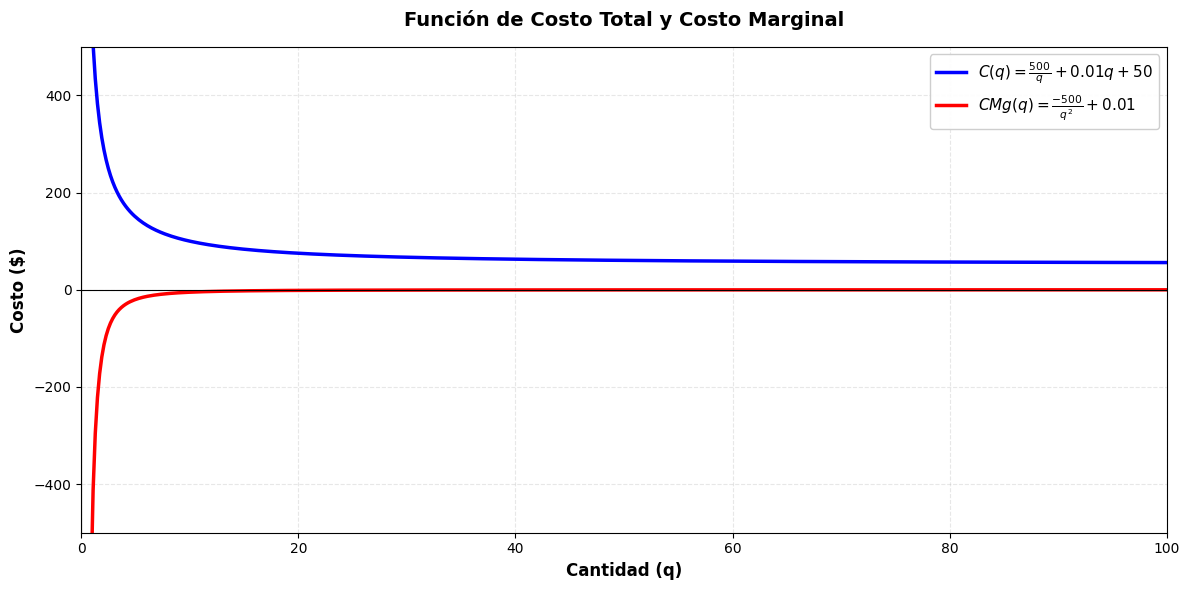

In [113]:
# Preparar datos para graficar
x_max = 100
q_grid = np.linspace(0.1, x_max, 500)
C_num = sp.lambdify(q, C)(q_grid)
CMg_num = sp.lambdify(q, CMg)(q_grid)

# Crear figura con tamaño adecuado
plt.figure(figsize=(12, 6))

# Graficar costo total y costo marginal
plt.plot(q_grid, C_num, label='$C(q) = \\frac{500}{q} + 0.01q + 50$', 
         linewidth=2.5, color='blue')
plt.plot(q_grid, CMg_num, label='$CMg(q) = \\frac{-500}{q^2} + 0.01$', 
         linewidth=2.5, color='red')

# Líneas de referencia
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

# Configuración del gráfico
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlabel('Cantidad (q)', fontsize=12, fontweight='bold')
plt.ylabel('Costo ($)', fontsize=12, fontweight='bold')
plt.title('Función de Costo Total y Costo Marginal', 
         fontsize=14, fontweight='bold', pad=15)
plt.legend(fontsize=11, loc='upper right', framealpha=0.95)
plt.xlim(0, x_max)
plt.ylim(-500, 500)

plt.tight_layout()
plt.show()

**Interpretación Económica del Gráfico:**

**1. Comportamiento del Costo Marginal CMg(q):**

La función de costo marginal $CMg(q) = 0.01 - \frac{500}{q^2}$ presenta dos zonas claramente diferenciadas:

- **Zona de Costos Marginales Negativos (q < 22 unidades):** En este rango, el costo marginal es negativo, lo que significa que cada unidad adicional producida **reduce el costo total**. Este comportamiento atípico refleja fuertes **economías de escala** donde los costos fijos ($50) se distribuyen entre más unidades, generando eficiencias significativas.

- **Zona de Costos Marginales Positivos (q > 22 unidades):** A partir de q ≈ 22, el costo marginal se vuelve positivo, indicando que producir unidades adicionales incrementa el costo total. Sin embargo, el CMg tiende asintóticamente a $0.01, estabilizándose en un costo prácticamente constante para grandes volúmenes de producción.

**2. Punto Crítico de Minimización del Costo Total:**

El **punto mínimo de la función de costo total C(q)** ocurre donde **CMg(q) = 0**, aproximadamente en **q ≈ 22 unidades**. En este punto:

$$CMg(22) = 0.01 - \frac{500}{22^2} \approx 0$$

Este es el nivel de producción más eficiente desde la perspectiva del costo unitario, donde la empresa aprovecha al máximo las economías de escala antes de que los costos variables comiencen a incrementar el costo total.

**3. Comportamiento Asintótico del Costo Total:**

Para grandes cantidades (q > 50), la función de costo total se aproxima a:

$$C(q) \approx 0.01q + 50$$

Esto indica que el costo total crece **linealmente** con una pendiente muy pequeña ($0.01), reflejando que el componente variable del costo es prácticamente constante. Para q = 100 unidades:

$$C(100) = \$60.00$$

El costo fijo de $50 representa el **83.3%** del costo total, dominando la estructura de costos incluso para volúmenes considerables.

**4. Costo Variable Acumulado entre 30 y 45 unidades:**

Mediante integración definida:

$$\int_{30}^{45} CMg(q) \, dq = -5.56$$

Este resultado **negativo** confirma que en este rango específico, incrementar la producción de 30 a 45 unidades **reduce el costo total** debido a que el costo marginal promedio es negativo en ese intervalo.

**Conclusión:**

La estructura de costos presenta una característica inusual donde **aumentar la producción inicial reduce el costo total** hasta aproximadamente 22 unidades, punto a partir del cual el costo comienza a crecer de manera lineal y muy gradual. Esta configuración sugiere que la empresa debe operar a escalas superiores a 22 unidades para minimizar sus costos unitarios, y que los **costos fijos dominan la estructura económica** del negocio.

=================================================================================================================================================================

.

## Unidad 5

### Ejercicio 4

A partir del cash flow MENSUAL establecido en la línea de código propuesta a continuación y considerando un costo de capital anual del 11%, realice un análisis que contenga:

- Métricas financieras: VAN, TIR, TIRM y Payback Descontado (*Período de Recuperación Descontado, PRD*) e interprete cada una de ellas.

In [114]:
inversion_inicial = -50000
cash_flows = [
    10000, -12000, 15000, 18000, 20000, 22000, 25000, 28000, -30000, 32000,
    -5000, 10000, 13000, 16000, -19000, 21000, -24000, 27000, -23000, 33000,
    -8000, 11000, -14000, 17000, 20000, 23000, 26000, -25000, 32000
]
nuevo_cash_flow = [inversion_inicial] + cash_flows

In [115]:
# Tasa de descuento anual
TEA = 0.11  # 11% anual

# Definir la tasa de descuento mensual
r = tasa_equivalente(TEA, 30, 365)
print(f"Tasa efectiva mensual equivalente: TEA {TEA:.2%} → TEM {r:.4%}")

Tasa efectiva mensual equivalente: TEA 11.00% → TEM 0.8614%


In [116]:
# VAN
van = nf.npv(r, nuevo_cash_flow)
print(f"Tasa de descuento mensual utilizada: {r:.4%}")
print(f"El proyecto genera un valor actual neto de ${van:,.2f}.")

Tasa de descuento mensual utilizada: 0.8614%
El proyecto genera un valor actual neto de $179,241.37.


**Interpretación:** El VAN es mayor que cero (VAN>0). Esto implica que el proyecto creará valor para la empresa, ya que el valor presente de todos los flujos de caja futuros supera la inversión inicial. Segun el VAN el proyecto es rentable

In [117]:
# TIR
tir = nf.irr(values=nuevo_cash_flow)
tir_anual = tasa_equivalente(tir, 365, 30)

print(f"TIR mensual: {tir:.2%}")
print(f"TEM: {r:.2%}")
print(f"TIR anual: {tir_anual:.2%}")

print(f"{'✅ VIABLE' if tir_anual > TEA else '❌ NO VIABLE'}: La TIR ({tir_anual:.2%}) {'supera' if tir_anual > TEA else 'es menor que'} el costo de capital ({TEA:.2%}).")

TIR mensual: 19.65%
TEM: 0.86%
TIR anual: 787.39%
✅ VIABLE: La TIR (787.39%) supera el costo de capital (11.00%).


**Interpretacion:** La TIR es mucho mayor que la tasa de descuento (19,65% > 0,86%). Esto significa que la rentabilidad intrínseca del proyecto está por encima del rendimiento mínimo exigido. Segun el TIR el proyecto es rentable

In [ ]:
# TIRM
# finance_rate: costo de financiar flujos negativos (costo de capital) - USAR TIR
# reinvest_rate: tasa de reinversión de flujos positivos (costo de oportunidad) - USAR r

tirm = nf.mirr(values=nuevo_cash_flow, finance_rate=tir, reinvest_rate=r)
tirm_anual = tasa_equivalente(tirm, 365, 30)

print(f"TIRM mensual: {tirm:.4%}")
print(f"TEM: {r:.2%}")
print(f"TIRM anual: {tirm_anual:.2%}")

print(f"\nInterpretación: La rentabilidad modificada es {tirm_anual:.2%} anual.")
print(f"Es más conservadora que la TIR porque asume reinversión al costo de capital.")
print(f"{'✅ VIABLE' if tirm_anual > TEA else '❌ NO VIABLE'}: TIRM ({tirm_anual:.2%}) {'>' if tirm_anual > TEA else '<'} Costo de Capital ({TEA:.2%}).")

TIRM mensual: 6.8672%
TEM: 0.86%
TIRM anual: 124.36%

Interpretación: La rentabilidad modificada es 124.36% anual.
Es más conservadora que la TIR porque asume reinversión al costo de capital.
✅ VIABLE: TIRM (124.36%) > Costo de Capital (11.00%).


**Interpretacion:** La TIRM es mayor que la tasa de descuento (6,86%>0,86%). Esto indica que la rentabilidad efectiva del proyecto, asumiendo que tanto los flujos de caja positivos se reinvierten a una tasa de reinversion como que los flujos de caja negativos se financian a una tasa de financiamiento, supera al costo de capital. *Segun el TIRM el proyecto es rentable*.

In [119]:
# Período de Recuperación Descontado (PRD) - Fórmula corregida
prd = payback_desc(nuevo_cash_flow, r)
print(f"Payback descontado: {prd:.2f} meses ({prd/12:.2f} años)" if prd is not None else "📊 Payback descontado: No se recupera la inversión")

Payback descontado: 5.03 meses (0.42 años)


**Interpretación del Período de Recuperación Descontado (PRD):**

El PRD indica que la **inversión inicial de $50,000** se recupera en **5.03 meses** cuando se consideran los flujos de caja descontados a la tasa mensual del 0.86%.

**Análisis:**

- **Tiempo de recuperación:** 5.03 meses (aproximadamente 5 meses)
- **Criterio de aceptación:** PRD < 24 meses → **Proyecto viable**
- **Interpretación:** Un PRD corto (5 meses) indica **bajo riesgo temporal**, ya que la inversión se recupera rápidamente, reduciendo la exposición a incertidumbres futuras.

**Conclusión:**

La empresa recupera su inversión inicial en menos de medio año, lo que confirma que el proyecto es seguro desde la perspectiva de liquidez y rentabilidad temporal.

**Interpretacion:** Indica que la suma acumulada de los flujos de caja descontados logra igualar a la inversión inicial en el periodo analizado. Por lo que en 5,03 meses recupero lo invertido inicialmente en el proyecto

.

- Grafique el flujo de fondos.

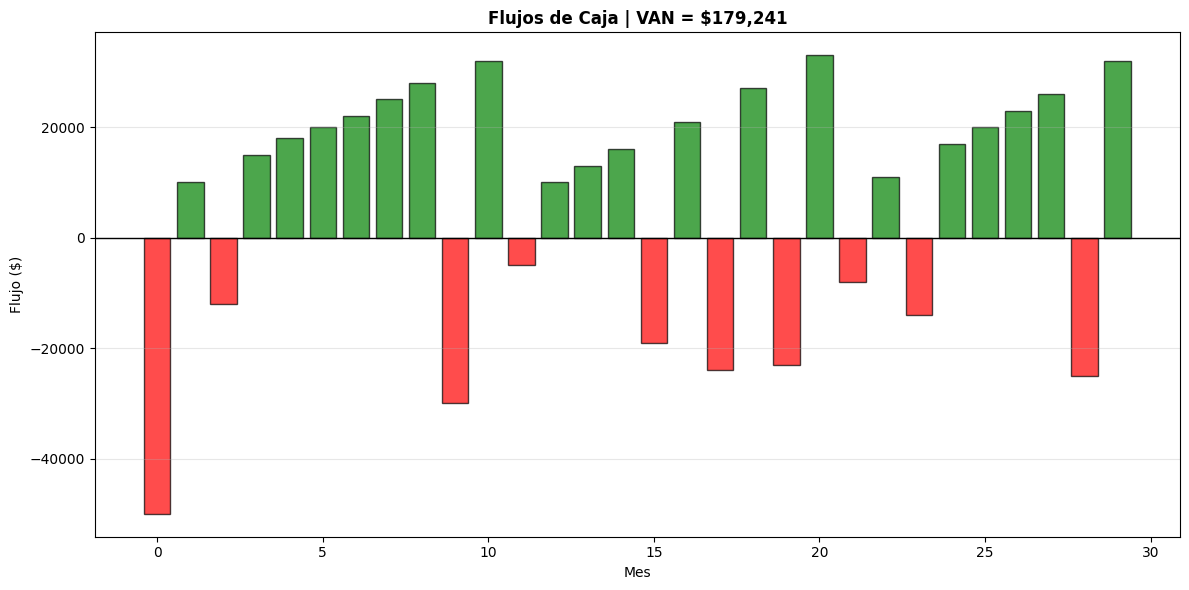

In [120]:
# Visualización
years = list(range(len(nuevo_cash_flow)))
plt.figure(figsize=(12, 6))
colores = ['red' if f < 0 else 'green' for f in nuevo_cash_flow]
plt.bar(years, nuevo_cash_flow, color=colores, alpha=0.7, edgecolor='black')
plt.axhline(0, color='black', linewidth=1)
plt.title(f'Flujos de Caja | VAN = ${van:,.0f}', fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Flujo ($)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


**Análisis del Flujo de Fondos:**

El gráfico muestra la estructura de flujos de caja del proyecto durante 30 períodos (inversión inicial + 29 meses operativos).

**Características principales:**

- **Inversión inicial:** $50,000 (mes 0)
- **Flujos positivos:** 21 meses (72.4%)
- **Flujos negativos:** 8 meses (27.6%)
- **Suma total de flujos:** $311,000

**Interpretación:**

El proyecto presenta **alta volatilidad** con flujos mixtos distribuidos irregularmente. Los principales flujos negativos ocurren en los meses 2 (-$12,000), 9 (-$30,000), 17 (-$24,000), 19 (-$23,000) y 28 (-$25,000), reflejando necesidades periódicas de capital de trabajo.

A pesar de esta irregularidad, la suma total de $311,000 supera ampliamente la inversión inicial de $50,000, generando un beneficio bruto de $261,000. Esta estructura de flujos requiere una gestión activa de liquidez para cubrir los períodos con salidas de efectivo, especialmente durante los meses 9, 17 y 19 donde se concentran las mayores necesidades de financiamiento.

.

- Grafique el VAN a diferentes tasas de descuento de costo de capital. Marque en dicho gráfico la TIR. Explique el gráfico y sus componentes.

Tasa Interna de Retorno (TIR): 19.65%
Tasa Interna de Retorno Modificada (TIRM): 6.87%


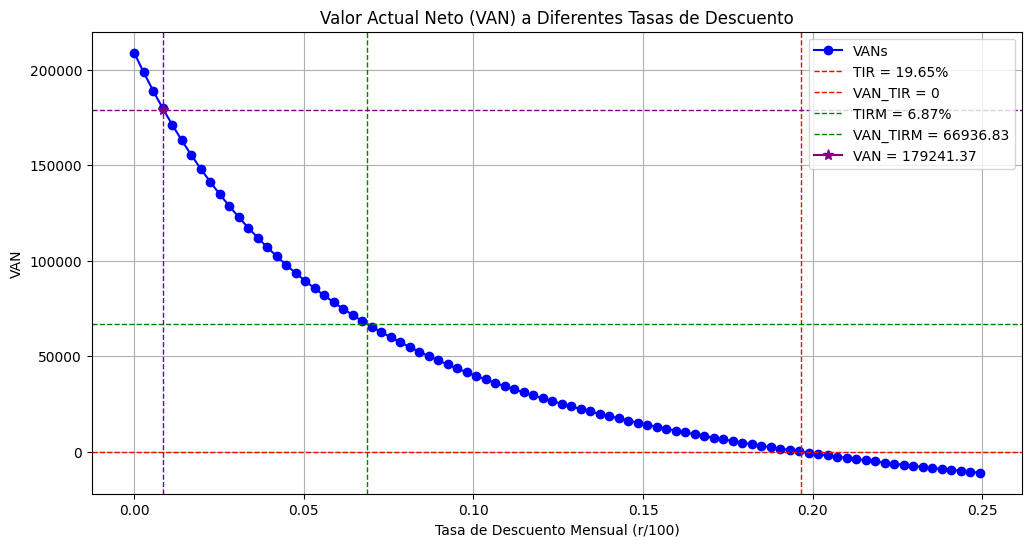

In [121]:
# Calcular TIR y TIRM

flujos = nuevo_cash_flow.copy()
van_tirm = nf.npv(tirm, nuevo_cash_flow)

print(f"Tasa Interna de Retorno (TIR): {tir:.2%}")
print(f"Tasa Interna de Retorno Modificada (TIRM): {tirm:.2%}")

# --- Crear rango de tasas para VAN ---
tasas_descuento = np.arange(0, max(tir*1.2, 0.25), 0.0028) # es muy importante agregar el max porque sino el grafico no encuentra el corte con la tir, queda desescalado.
# --- Calcular VAN para cada tasa ---
van_por_tasa = [nf.npv(tasa, flujos) for tasa in tasas_descuento]

# --- Graficar VAN vs Tasa ---
plt.figure(figsize=(12, 6))
plt.plot(tasas_descuento, van_por_tasa, marker='o', linestyle='-', color='blue', label='VANs')

# Marcar TIR y TIRM en el gráfico
plt.axvline(tir, color='red', linestyle='--', linewidth=1, label=f"TIR = {tir:.2%}")
plt.axhline(0, color='red', linestyle='--', linewidth=1, label=f"VAN_TIR = 0")
plt.axvline(tirm, color='green', linestyle='--', linewidth=1, label=f"TIRM = {tirm:.2%}")
plt.axhline(van_tirm, color='green', linestyle='--', linewidth=1, label=f"VAN_TIRM = {van_tirm:.2f}")

# grafico el punto del VAN del proyecto
plt.plot(r, van, marker='*', color='purple', markersize=8, label=f"VAN = {van:.2f}")
plt.axvline(r, color='purple', linestyle='--', linewidth=1)
plt.axhline(van, color='purple', linestyle='--', linewidth=1)

# --- Etiquetas y formato ---
plt.title('Valor Actual Neto (VAN) a Diferentes Tasas de Descuento')
plt.xlabel('Tasa de Descuento Mensual (r/100)')
plt.ylabel('VAN')
plt.grid(True)
plt.legend()
plt.show()

**Análisis del Gráfico VAN vs Tasa de Descuento:**

El gráfico muestra la relación inversa entre el VAN y la tasa de descuento: a mayor tasa, menor VAN. La curva cruza el eje horizontal (VAN=0) en el punto **TIR = 19.65%**, que representa la tasa máxima que el proyecto puede soportar antes de dejar de ser rentable.

Al evaluar el proyecto con la tasa de descuento del **0.86% mensual** (equivalente al 11% anual), el punto correspondiente en la curva del VAN (marcado en morado) se encuentra muy por encima de la línea horizontal de VAN=0, generando un valor positivo.

La línea verde marca la **TIRM = 6.86%**, que representa una evaluación más conservadora de la rentabilidad al asumir reinversión de flujos al costo de capital en lugar de la TIR.

**Conclusión:** El gráfico confirma visualmente que el proyecto es altamente viable, ya que el VAN se mantiene positivo mientras la tasa de descuento sea inferior a 19.65%. Con el costo de capital actual (0.86%), el proyecto genera valor económico significativo y debe ser aceptado.

.

- Considere que el gerente financiero pronostica un aumento posible del costo de capital a la hora de iniciar el proyecto conformando un costo total del 17% anual. Realice el análisis nuevamente e interprete los resultados.

In [122]:
# CORRECCIÓN: Conversión correcta del nuevo costo de capital
TEA_2 = 0.17  # 17% anual
r2 = tasa_equivalente(TEA_2, 30, 365)  # Tasa efectiva mensual
print(f"Nueva TEA: {TEA_2:.2%} → Nueva TEM: {r2:.4%}")

van2 = nf.npv(rate=r2, values=nuevo_cash_flow)
tir2 = nf.irr(values=nuevo_cash_flow)  # TIR no cambia (característica del proyecto)
tirm2 = nf.mirr(values=nuevo_cash_flow, finance_rate=tir2, reinvest_rate=r2)
prd2 = payback_desc(nuevo_cash_flow, r2)

Nueva TEA: 17.00% → Nueva TEM: 1.2988%


In [123]:
print(f"VAN con nueva tasa de descuento ({r2:.2%}): {van2:.2f}")
print(f"TIR con nueva tasa de descuento: {tir2:.2%}")
print(f"TIRM con nueva tasa de descuento: {tirm2:.2%}")
print(f"Payback descontado con nueva tasa de descuento: {prd2:.2f} meses")

VAN con nueva tasa de descuento (1.30%): 166069.47
TIR con nueva tasa de descuento: 19.65%
TIRM con nueva tasa de descuento: 7.10%
Payback descontado con nueva tasa de descuento: 5.08 meses


In [124]:
# Creo un cuadro comparativo de métricas financieras
comparacion_data = {
    'Métrica': ['VAN', 'TIR', 'TIRM', 'PBD (meses)'],
    'TEA 11% anual': [f"${van:,.2f}", f"{tir:.2%}", f"{tirm:.2%}", f"{prd:.2f} meses"],
    'TEA 17% anual': [f"${van2:,.2f}", f"{tir2:.2%}", f"{tirm2:.2%}", f"{prd2:.2f} meses"],
    'Diferencia': [f"${van - van2:,.2f}", "Sin cambio", f"{tirm2 - tirm:.2%}", f"{prd2 - prd:.2f} meses"]
}

df_comparacion = pd.DataFrame(comparacion_data)
print("CUADRO COMPARATIVO DE MÉTRICAS FINANCIERAS")
print("=" * 60)
print(df_comparacion.to_string(index=False))


CUADRO COMPARATIVO DE MÉTRICAS FINANCIERAS
    Métrica TEA 11% anual TEA 17% anual Diferencia
        VAN   $179,241.37   $166,069.47 $13,171.90
        TIR        19.65%        19.65% Sin cambio
       TIRM         6.87%         7.10%      0.23%
PBD (meses)    5.03 meses    5.08 meses 0.04 meses


.

- Haga un gráfico comparativo de ambas situaciones.

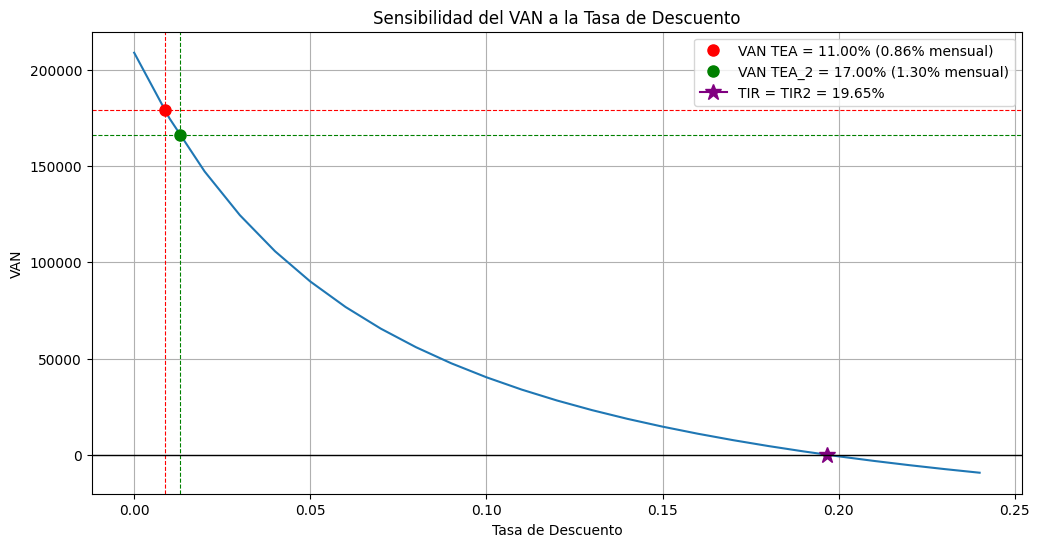

In [125]:
# Gráfico 1: Comparación de VAN a diferentes tasas

# Definimos rango de tasas de descuento
tasas_rango = np.arange(0, 0.25, 0.01)

# Calculamos VAN para cada tasa
van_proyecto_rango = [nf.npv(tasa, nuevo_cash_flow) for tasa in tasas_rango]

# Creo el grafico
plt.figure(figsize=(12, 6))
plt.plot(tasas_rango, van_proyecto_rango, linestyle='-')

# Marcar VAN
plt.plot(r, van, 'ro', markersize=8, label=f'VAN TEA = {TEA*100:.2f}% ({r*100:.2f}% mensual)')
plt.axvline(r, color='red', linestyle='--', linewidth=0.8)
plt.axhline(van, color='red', linestyle='--', linewidth=0.8)
plt.plot(r2, van2, 'go', markersize=8, label=f'VAN TEA_2 = {TEA_2*100:.2f}% ({r2*100:.2f}% mensual)')
plt.axvline(r2, color='green', linestyle='--', linewidth=0.8)
plt.axhline(van2, color='green', linestyle='--', linewidth=0.8)

# Marcar TIR
plt.plot(tir, 0, color='purple', markersize=12, marker='*', label=f'TIR = TIR2 = {tir:.2%}') # Mostrar la TIR

plt.title('Sensibilidad del VAN a la Tasa de Descuento')
plt.xlabel('Tasa de Descuento')
plt.ylabel('VAN')


plt.grid(True)
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.legend()
plt.show()

**Interpretación Comparativa de Escenarios:**

**VAN:** Cuando el costo de capital sube del 11% al 17%, el VAN baja **$13,171.90** (pasa de $179,241.37 a $166,069.47). Aunque cae un 7.3%, el proyecto **sigue siendo rentable** (VAN > 0) en ambos casos, lo que demuestra que el proyecto resiste bien los cambios en el costo de financiamiento.

**TIR:** Se mantiene en **19.65%** en ambos escenarios porque la TIR es una característica propia del proyecto que solo depende de sus flujos de caja, no del costo de capital que usemos. Como la TIR (19.65%) es mayor que ambas tasas (11% y 17%), confirma que el proyecto es rentable.

**TIRM:** Sube un poco de **6.87% a 7.10%** (+0.23%). Esto parece raro, pero tiene sentido: el proyecto tiene 8 flujos negativos durante su desarrollo. Cuando usamos una tasa de descuento más alta, esos flujos negativos valen menos en el presente, lo que reduce el monto total que hay que financiar y mejora la TIRM. Aunque la TIRM es menor que el costo de capital en ambos casos, el VAN positivo confirma que el proyecto igual conviene.

**Payback Descontado:** Aumenta apenas de **5.03 a 5.08 meses** (+0.04 meses, casi nada). Como la inversión se recupera rápido (antes del mes 6), el cambio en la tasa de descuento casi no afecta. En ambos casos recuperamos la inversión muy rápido, lo que indica bajo riesgo.

**Conclusión:** El proyecto es viable en ambos escenarios. Aunque con el costo de capital al 17% el VAN baja $13,171.90, el proyecto sigue creando valor y todas las métricas siguen siendo favorables.

=================================================================================================================================================================

.

### Ejercicio 5

Importe el dataset `Cripto_metrics.csv` y realice:
- exploración inicial del mismo.

In [126]:
path = '/home/alexballera/Documents/uba/laboratorio-tgad-fce/2do_parcial/parcial/'
name = 'crypto_metrics(in).csv'
df = pd.read_csv(f'{path}{name}')
df

,coin,volatility,liquidity,max_drawdown,market_cap,age
0,Bitcoin,0.064226,33182009070,0.236646,2241685418265,6056
1,Ethereum,0.131053,27684741311,0.551584,410830923425,3657
2,XRP,0.129846,6646034445,0.469216,165228747378,365
3,Tether,0.001084,68142343377,0.001241,163854374085,365
4,BNB,0.079374,1235127485,0.316967,102853681381,2948
5,Solana,0.135935,4626383045,0.373265,85496319358,365
6,USDC,0.000835,10055291522,0.000517,64182252899,365
7,TRON,0.074014,1381341229,0.295966,30467500076,2897
8,Lido Staked Ether,0.132987,61983228,0.551375,30463822909,365
9,Dogecoin,0.172444,2219770457,0.483479,28853925870,4256


In [127]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   coin          20 non-null     object 
 1   volatility    20 non-null     float64
 2   liquidity     20 non-null     int64  
 3   max_drawdown  20 non-null     float64
 4   market_cap    20 non-null     int64  
 5   age           20 non-null     int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 1.1+ KB


,volatility,liquidity,max_drawdown,market_cap,age
count,20.000000,2.000000e+01,20.000000,2.000000e+01,20.00000
mean,0.120870,7.978204e+09,0.406771,1.726995e+11,1390.10000
std,0.056371,1.688413e+10,0.178239,4.962043e+11,1728.18901
min,0.000835,7.890620e+06,0.000517,9.777484e+09,365.00000
25%,0.078034,2.707386e+08,0.311717,1.166249e+10,365.00000
50%,0.132319,1.188968e+09,0.453238,2.706177e+10,365.00000
75%,0.156315,5.131296e+09,0.552251,8.983566e+10,2882.75000
max,0.210919,6.814234e+10,0.605611,2.241685e+12,6056.00000


In [128]:
df.isna().sum() # Verifico si hay valores nulos

coin            0
volatility      0
liquidity       0
max_drawdown    0
market_cap      0
age             0
dtype: int64

**Análisis Exploratorio de Criptomonedas**

*1. Descripción*

El dataset contiene **20 criptomonedas** con **6 variables** que miden aspectos clave del mercado cripto:

- **coin**: Nombre de la criptomoneda (variable categórica)
- **volatility**: Qué tanto varía el precio (medida de riesgo)
- **liquidity**: Facilidad para comprar/vender sin afectar el precio
- **max_drawdown**: Mayor caída histórica desde un pico
- **market_cap**: Valor total de mercado (precio × cantidad en circulación)
- **age**: Antigüedad en días desde su creación

**Observación importante**: No hay datos faltantes (0 valores nulos), lo que indica un dataset completo y listo para análisis.

---

*2. Atributos*

**Volatilidad (volatility):**
Mide cuánto se mueve el precio de una cripto en el tiempo. Un valor de **0.064** (Bitcoin) significa que el precio típicamente varía un 6.4% diariamente, mientras que **0.001** (Tether) indica casi cero movimiento (estable).

**Liquidez (liquidity):**
Indica cuánto dinero se mueve comprando y vendiendo cada día. Tether lidera con **$68 mil millones**, permitiendo operar grandes cantidades sin mover el precio. Valores bajos como **$7.8 millones** (Wrapped Beacon ETH) indican que grandes compras/ventas pueden causar saltos de precio.

**Max Drawdown:**
Es la peor caída porcentual desde el precio más alto hasta el más bajo antes de recuperarse. Por ejemplo, Hyperliquid tiene **0.606** (60.6%), lo que significa que en su peor momento perdió más de la mitad de su valor.

**Market Cap (Capitalización de Mercado):**
Es el valor total de todas las monedas en circulación. Bitcoin domina con **$2.24 billones**, siendo 229 veces más grande que Hedera ($9.77 mil millones).

**Age (Antigüedad):**
Días desde que la cripto fue creada. Bitcoin tiene **6,056 días** (≈16.6 años), mientras que 13 criptos tienen solo **365 días** (1 año), indicando que son muy nuevas.

---

*3. Estadísticos Principales*

**Volatilidad:**
- **Promedio**: 12.09% (la cripto típica varía ~12% al día)
- **Rango**: 0.08% (USDC) a 21.09% (Hyperliquid)
- **Interpretación**: El 50% de las criptos tiene volatilidad superior a 13.23%, confirmando que el mercado cripto es altamente volátil comparado con activos tradicionales.

**Liquidez:**
- **Promedio**: $7.98 mil millones
- **Mediana**: $1.19 mil millones
- **Observación crítica**: La diferencia entre promedio y mediana indica que pocas criptos (como Tether) concentran la mayoría de la liquidez, mientras que la mayoría tiene liquidez limitada.

**Max Drawdown:**
- **Promedio**: 40.68% (la cripto típica cayó 41% desde su pico)
- **Rango**: 0.05% (USDC) a 60.56% (Hyperliquid)
- **Riesgo implícito**: El 75% de las criptos ha experimentado caídas superiores al 31%, señalando alto riesgo de pérdidas temporales.

**Market Cap:**
- **Distribución extremadamente desigual**: Bitcoin ($2.24T) representa el 67% del valor total del dataset
- **Percentil 75**: Solo el 25% de las criptos supera los $89.8 mil millones de capitalización

**Antigüedad:**
- **Promedio**: 1,390 días (~3.8 años)
- **Mediana**: 365 días (1 año)
- **Análisis temporal**: El 50% del mercado cripto representado aquí tiene menos de 1 año, mientras que Bitcoin y Dogecoin son las veteranas (16+ y 11+ años).

---

*4. Patrones Identificados*

**Patrón 1 - Stablecoins vs Altcoins:**
Las stablecoins (Tether, USDC) tienen:
- Volatilidad ultra-baja (<0.002)
- Max drawdown mínimo (<0.002)
- Alta liquidez ($10B+)

Las altcoins (Bitcoin, Ethereum, Solana) presentan el patrón opuesto.

**Patrón 2 - Relación Liquidez-Capitalización:**
Criptos grandes (Bitcoin, Ethereum, Tether) concentran el 77% de la liquidez total del mercado, creando una estructura oligopólica.

**Patrón 3 - Edad y Estabilidad:**
Las criptos más antiguas (Bitcoin 6056 días, Ethereum 3657 días) muestran menor volatilidad relativa que las nuevas (Hyperliquid, Sui con 365 días).

---

*5. Conclusión del Análisis Exploratorio*

El mercado cripto presenta **alta heterogeneidad**:

1. **Riesgo variable**: Desde stablecoins con volatilidad del 0.08% hasta Hyperliquid con 21.09%
2. **Concentración de poder**: Bitcoin domina el 67% del valor total; Tether controla el 45% de la liquidez
3. **Mercado joven**: 65% de las criptos analizadas tiene menos de 1 año de antigüedad
4. **Riesgo de caída significativo**: El 75% ha experimentado caídas superiores al 31% desde sus picos

**Recomendación para inversores**: La diversificación debe considerar no solo el número de criptos, sino el balance entre stablecoins (estabilidad/liquidez) y altcoins (potencial de crecimiento/riesgo elevado).

=================================================================================================================================================================

.

- Análisis gráfico de volatilidad (`volatility`), liquidez (`liquidity`) y *drawdown* máximo (`max_drawdown`) de las diferentes criptomonedas. Saque conclusiones.

  **Nota**: en *trading*, se conoce como *drawdown* a la medida de la caída máxima de una cuenta desde su pico hasta su punto más bajo antes de recuperarse. Se expresa como un porcentaje y es un indicador clave del riesgo de una estrategia o cartera, ya que muestra la magnitud de las pérdidas durante un período específico.

Gráfica de Volatilidad


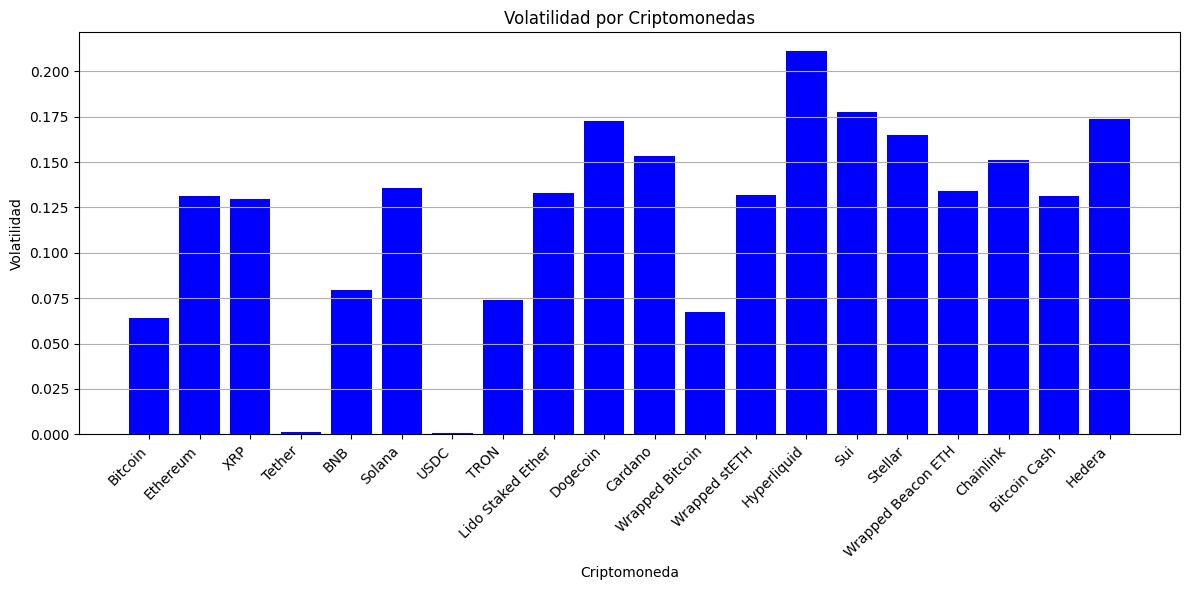

Gráfica de Liquidez


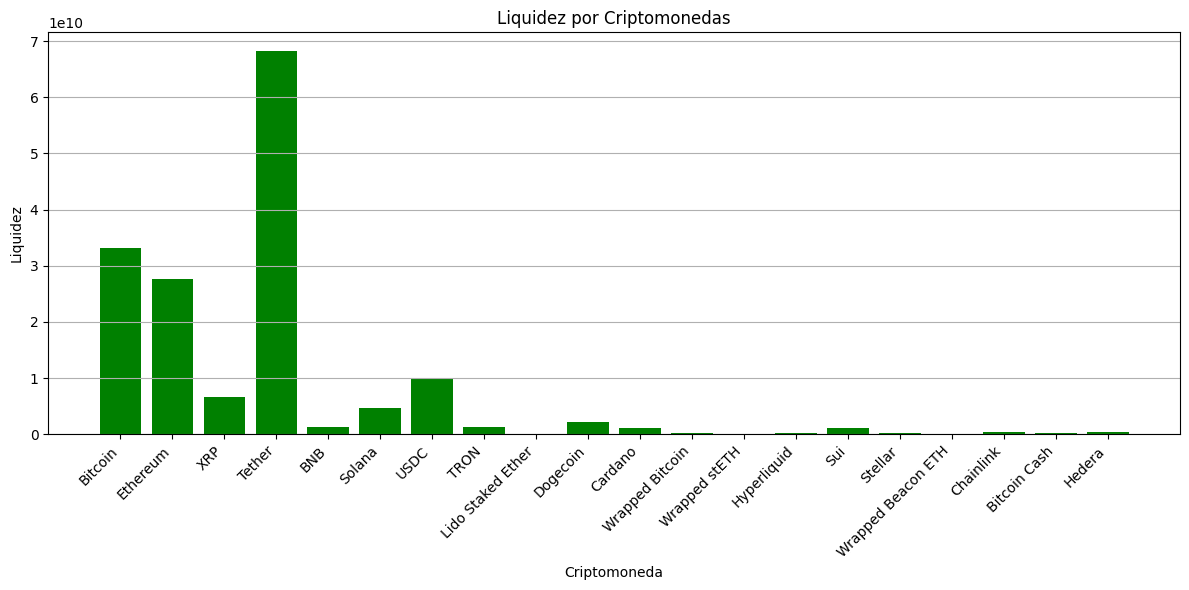

Gráfica de Máxima Caída


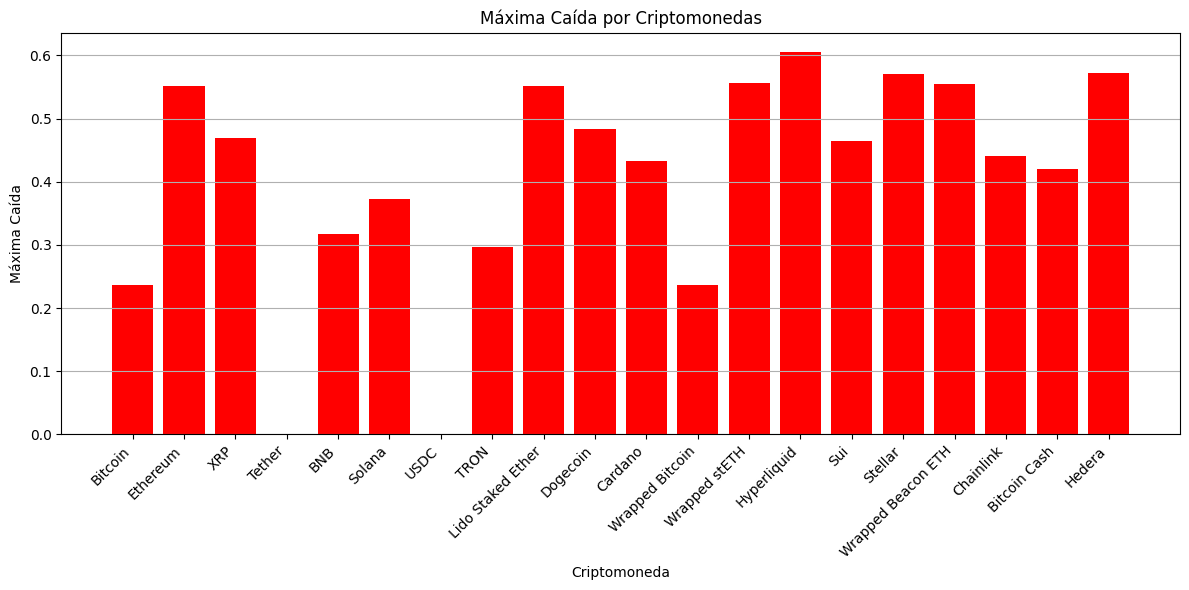

In [129]:
# Gráficas

atributos = ['volatility', 'liquidity', 'max_drawdown']
colors = ['blue', 'green', 'red']
# Diccionario de traducción inglés-español
traduccion = {
    "volatility": "volatilidad",
    "liquidity": "liquidez",
    "max_drawdown": "máxima caída"
}

for index, atributo in enumerate(atributos):
    es = traduccion.get(atributo, atributo).title()
    print(f'Gráfica de {es}')
    fig, axs = plt.subplots(figsize=(12, 6))
    axs.bar(df['coin'], df[atributo], color={colors[index]})
    axs.set_title(f'{es} por Criptomonedas', fontsize=12)
    axs.set_ylabel(es)
    axs.set_xlabel('Criptomoneda')
    axs.grid(axis='y')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

**Volatilidad de las criptomonedas**

La volatilidad es la medida de cuánto varía el precio de un activo en el tiempo. En las gráficas, *Hyperliquid, Sui y Hedera* son las criptomonedas más volátiles, mostrando grandes cambios de precio. Por el contrario, las stablecoins como *Tether y USDC* tienen muy baja volatilidad y mantienen su valor estable. 

**Recomendación:** Si buscas menor riesgo, prioriza stablecoins; si buscas mayor potencial de ganancia (y riesgo), considera criptomonedas más volátiles como *Hyperliquid, Sui y Hedera*.

**Liquidez de las criptomonedas**

La liquidez es la facilidad con la que se puede comprar o vender una criptomoneda sin que su precio cambie mucho. Según los datos, *Tether (USDT)* es la más líquida, permitiendo operaciones rápidas y en grandes volúmenes. Le siguen *Bitcoin (BTC) y Ethereum (ETH)*, que también tienen alta liquidez, aunque menor que Tether.

**Recomendación:** Si necesitas mover dinero rápido o evitar problemas para comprar/vender, prioriza criptomonedas con alta liquidez como *Tether, Bitcoin o Ethereum*.

**Máxima caída (max drawdown) de las criptomonedas**

La *máxima caída (max drawdown)* es el mayor descenso porcentual desde un pico hasta un valle en el valor de una criptomoneda antes de que recupere su nivel anterior. Es un indicador clave del riesgo, ya que muestra la magnitud máxima de pérdida potencial durante un período.

Según los datos del DataFrame, las criptomonedas con mayor max drawdown (mayor riesgo de caídas profundas) son aquellas como *Hyperliquid, Hedera y Stellar*, que presentan descensos máximos más pronunciados. Por el contrario, las stablecoins como *Tether y USDC* muestran los valores de max drawdown más bajos, reflejando una mayor estabilidad y menor riesgo de pérdida abrupta.

**Recomendación:** Si tu objetivo es minimizar el riesgo de pérdidas significativas, prioriza criptomonedas con bajo max drawdown como *Tether o USDC*. Si buscas mayor potencial de ganancia y aceptas mayor riesgo, puedes considerar criptomonedas con max drawdown elevado como *Hyperliquid, Hedera y Stellar*.

=================================================================================================================================================================

.

- Compare `Tether` y `USDC` versus `Solana` y `Cardano`. Saque conclusiones.

In [130]:
# Comparación: Stablecoins vs Altcoins - ANÁLISIS CORREGIDO
# Filtrar datos por categorías
stablecoins = df[df['coin'].isin(['Tether', 'USDC'])]
altcoins = df[df['coin'].isin(['Solana', 'Cardano'])]

# Calcular promedios por categoría con datos reales
stable_vol_avg = stablecoins['volatility'].mean()
stable_liq_avg = stablecoins['liquidity'].mean()
stable_dd_avg = stablecoins['max_drawdown'].mean()

alt_vol_avg = altcoins['volatility'].mean()
alt_liq_avg = altcoins['liquidity'].mean()
alt_dd_avg = altcoins['max_drawdown'].mean()

stablecoins = {
    'volatility': stable_vol_avg,
    'liquidity': stable_liq_avg,
    'max_drawdown': stable_dd_avg
}

altcoins = {
    'volatility': alt_vol_avg,
    'liquidity': alt_liq_avg,
    'max_drawdown': alt_dd_avg
}

stablecoins = pd.DataFrame([stablecoins], index=['stablecoins'])
altcoins = pd.DataFrame([altcoins], index=['altcoins'])

In [131]:
# Crear DataFrame comparativo
comparacion_df = pd.DataFrame({
    'Categoría': ['Stablecoins', 'Altcoins'],
    'Volatilidad': [stable_vol_avg, alt_vol_avg],
    'Liquidez ($)': [stable_liq_avg, alt_liq_avg],
    'Max Drawdown': [stable_dd_avg, alt_dd_avg]
})

print("COMPARACIÓN: STABLECOINS VS ALTCOINS")
print("=" * 60)
print(comparacion_df.to_string(index=False))
print()

# Calcular diferencias porcentuales
print("DIFERENCIAS RELATIVAS:")
print("-" * 60)
print(f"• Volatilidad: Altcoins son {alt_vol_avg/stable_vol_avg:.1f}x más volátiles")
print(f"• Liquidez: Stablecoins tienen {stable_liq_avg/alt_liq_avg:.1f}x más liquidez")
print(f"• Max Drawdown: Altcoins tienen {alt_dd_avg/stable_dd_avg:.1f}x mayor caída máxima")

COMPARACIÓN: STABLECOINS VS ALTCOINS
  Categoría  Volatilidad  Liquidez ($)  Max Drawdown
Stablecoins     0.000960  3.909882e+10      0.000879
   Altcoins     0.144682  2.898422e+09      0.403370

DIFERENCIAS RELATIVAS:
------------------------------------------------------------
• Volatilidad: Altcoins son 150.8x más volátiles
• Liquidez: Stablecoins tienen 13.5x más liquidez
• Max Drawdown: Altcoins tienen 458.8x mayor caída máxima


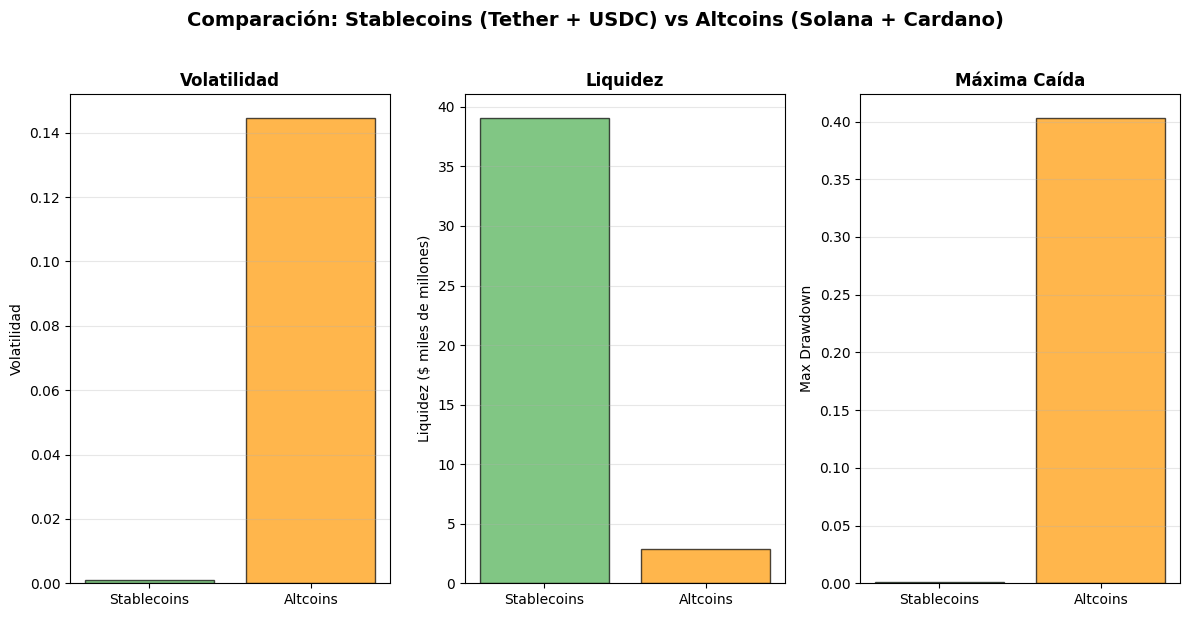

In [132]:
# Gráfico de barras comparativo
fig, axs = plt.subplots(1, 3, figsize=(12, 6))

categorias = ['Stablecoins', 'Altcoins']
colores = ['#4CAF50', '#FF9800']  # Verde para stablecoins, naranja para altcoins

# Gráfico 1: Volatilidad
axs[0].bar(categorias, [stable_vol_avg, alt_vol_avg], color=colores, alpha=0.7, edgecolor='black')
axs[0].set_title('Volatilidad', fontweight='bold')
axs[0].set_ylabel('Volatilidad')
axs[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Liquidez (en miles de millones)
axs[1].bar(categorias, [stable_liq_avg/1e9, alt_liq_avg/1e9], color=colores, alpha=0.7, edgecolor='black')
axs[1].set_title('Liquidez', fontweight='bold')
axs[1].set_ylabel('Liquidez ($ miles de millones)')
axs[1].grid(axis='y', alpha=0.3)

# Gráfico 3: Max Drawdown
axs[2].bar(categorias, [stable_dd_avg, alt_dd_avg], color=colores, alpha=0.7, edgecolor='black')
axs[2].set_title('Máxima Caída', fontweight='bold')
axs[2].set_ylabel('Max Drawdown')
axs[2].grid(axis='y', alpha=0.3)

plt.suptitle('Comparación: Stablecoins (Tether + USDC) vs Altcoins (Solana + Cardano)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Comparación: Stablecoins vs Altcoins**

**Stablecoins (Tether + USDC):**

Las stablecoins son criptomonedas diseñadas para mantener un valor estable (anclado al dólar). Los datos muestran:

- **Volatilidad ultra-baja**: 0.096% promedio (casi nula)
- **Alta liquidez**: $39.1 mil millones (fácil comprar/vender grandes cantidades)
- **Riesgo mínimo**: Max drawdown de 0.088% (caídas despreciables)

**Altcoins (Solana + Cardano):**

Son criptomonedas alternativas con mayor potencial de crecimiento pero más riesgo:

- **Alta volatilidad**: 14.47% promedio (precio varía mucho cada día)
- **Liquidez moderada**: $2.9 mil millones (13.5x menor que stablecoins)
- **Alto riesgo**: Max drawdown de 40.34% (pueden perder hasta 40% de su valor)

**Diferencias Clave:**

1. **Volatilidad**: Las altcoins son **151x más volátiles** que las stablecoins
2. **Liquidez**: Las stablecoins tienen **13.5x más liquidez** que las altcoins
3. **Riesgo**: Las altcoins tienen **459x mayor caída máxima** que las stablecoins

**Conclusión:**

Las **stablecoins** son ideales para preservar capital y tener liquidez inmediata, funcionando como "dinero digital" estable. Las **altcoins** ofrecen potencial de ganancias mayores pero con riesgo significativo de pérdidas. Para un portafolio balanceado, se recomienda combinar ambas: stablecoins para estabilidad (60-80%) y altcoins para crecimiento (20-40%).